# 🛒 Analyse des Performances E-commerce — ElecMart Retail
> **Projet Portfolio Data Analyst** · Secteur Retail & E-commerce · 2024  
> **Stack :** Python · Pandas · Matplotlib · Seaborn  
> **Dataset :** ElecMart Retail Analytics — Kaggle (1.8M lignes de ventes, 500K sessions, 150K clients)

---

## 🎯 Problématique

> *"Comment optimiser les performances d'un e-commerce retail en analysant le comportement des visiteurs, les sources de trafic et la rentabilité produit ?"*

---

## 📋 Plan d'analyse

1. **Chargement & Exploration des données**
2. **KPIs globaux**
3. **Entonnoir de conversion**
4. **Performance par device**
5. **Analyse des sources de trafic**
6. **Comportement par heure**
7. **Évolution revenus & marge**
8. **Segmentation clients**
9. **Top produits par marge**
10. **Heatmap segment × canal**
11. **Insights & Recommandations**


## 1. 📦 Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Palette couleurs pro ──────────────────────────────────
NAVY   = '#1E2D5A'
TEAL   = '#0D7377'
GREEN  = '#14A085'
ORANGE = '#E8813A'
LIGHT  = '#F7F9FC'
GRAY   = '#95A5A6'

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.facecolor'    : LIGHT,
    'figure.facecolor'  : 'white',
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.titlecolor'   : NAVY,
    'axes.labelcolor'   : NAVY,
    'xtick.color'       : NAVY,
    'ytick.color'       : NAVY,
})

print('✅ Librairies importées')


✅ Librairies importées


## 2. 📂 Chargement & Exploration des Données

### Structure du dataset

| Fichier | Description | Volume |
|---------|-------------|--------|
| `fact_clickstream_sample.csv` | Sessions web — comportement visiteurs | 500K lignes |
| `fact_sale.csv` | Transactions de vente | 1.8M lignes |
| `dim_customer.csv` | Profil clients | 150K lignes |
| `dim_product.csv` | Catalogue produits | 470 lignes |


In [2]:
# Chargement des données
clicks    = pd.read_csv('fact_clickstream_sample.csv')
sales     = pd.read_csv('fact_sale.csv')
customers = pd.read_csv('dim_customer.csv')
products  = pd.read_csv('dim_product.csv')

print('=== APERÇU DES DATASETS ===')
for name, df in [('fact_clickstream', clicks), ('fact_sale', sales),
                 ('dim_customer', customers), ('dim_product', products)]:
    print(f'  {name:<25} {df.shape[0]:>10,.0f} lignes × {df.shape[1]} colonnes')


=== APERÇU DES DATASETS ===
  fact_clickstream             500,000 lignes × 15 colonnes
  fact_sale                  1,799,836 lignes × 12 colonnes
  dim_customer                 150,000 lignes × 16 colonnes
  dim_product                      470 lignes × 9 colonnes


In [3]:
# Préparation des données
clicks['session_start_time']   = pd.to_datetime(clicks['session_start_time'])
clicks['session_end_time']     = pd.to_datetime(clicks['session_end_time'])
clicks['session_duration_min'] = (clicks['session_end_time'] - clicks['session_start_time']).dt.total_seconds() / 60
clicks['hour']  = clicks['session_start_time'].dt.hour
clicks['month'] = clicks['session_start_time'].dt.month

sales['transaction_timestamp'] = pd.to_datetime(sales['transaction_timestamp'])
sales['month_str'] = sales['transaction_timestamp'].dt.to_period('M').astype(str)
sales['margin']    = sales['line_total'] - sales['line_cost']

# Jointures : sales → clickstream → customers + products
sales_full = sales.merge(
    clicks[['session_id','customer_id','device_type','traffic_source']].dropna(subset=['customer_id']),
    on='session_id', how='left')
sales_full = sales_full.merge(
    products[['product_id','product_name','product_segment']], on='product_id', how='left')
sales_full = sales_full.merge(
    customers[['customer_id','loyalty_status','customer_persona','gender','signup_channel']],
    on='customer_id', how='left')

print('✅ Données préparées')
print(f'   sales_full : {sales_full.shape[0]:,.0f} lignes × {sales_full.shape[1]} colonnes')


✅ Données préparées
   sales_full : 1,799,836 lignes × 23 colonnes


In [4]:
# Exploration rapide
print('=== CLICKSTREAM — Colonnes ===')
print(clicks.dtypes)
print('\n=== CLICKSTREAM — Aperçu ===')
clicks.head(3)


=== CLICKSTREAM — Colonnes ===
session_id                            int64
customer_id                         float64
session_start_time           datetime64[ns]
session_start_date_id                 int64
session_end_time             datetime64[ns]
session_end_date_id                   int64
device_type                          object
number_of_pages_viewed                int64
product_page_visited_flag              bool
added_to_cart_flag                     bool
purchased_flag                         bool
traffic_source                       object
linked_to_a_campaign_flag              bool
campaign_id                         float64
aov_category                         object
session_duration_min                float64
hour                                  int32
month                                 int32
dtype: object

=== CLICKSTREAM — Aperçu ===


,session_id,customer_id,session_start_time,session_start_date_id,session_end_time,session_end_date_id,device_type,number_of_pages_viewed,product_page_visited_flag,added_to_cart_flag,purchased_flag,traffic_source,linked_to_a_campaign_flag,campaign_id,aov_category,session_duration_min,hour,month
0,9000862,31327.0,2023-09-19 21:46:26,20230919,2023-09-19 21:54:26,20230919,Mobile,11,True,True,False,Paid Search,False,NaN,NaN,8.0,21,9
1,9000863,NaN,2023-08-06 14:50:06,20230806,2023-08-06 14:51:06,20230806,Mobile,3,False,False,False,Referral,False,NaN,NaN,1.0,14,8
2,9000864,106739.0,2023-10-18 06:30:51,20231018,2023-10-18 06:33:51,20231018,Tablet,6,True,True,True,Organic,False,NaN,High,3.0,6,10


In [5]:
print('=== VÉRIFICATION NULLS — CLICKSTREAM ===')
print(clicks.isnull().sum())
print('\n=== VALEURS UNIQUES CLÉS ===')
print('device_type    :', clicks['device_type'].value_counts().to_dict())
print('traffic_source :', clicks['traffic_source'].value_counts().to_dict())
print('purchased_flag :', clicks['purchased_flag'].value_counts().to_dict())


=== VÉRIFICATION NULLS — CLICKSTREAM ===
session_id                        0
customer_id                  224678
session_start_time                0
session_start_date_id             0
session_end_time                  0
session_end_date_id               0
device_type                       0
number_of_pages_viewed            0
product_page_visited_flag         0
added_to_cart_flag                0
purchased_flag                    0
traffic_source                    0
linked_to_a_campaign_flag         0
campaign_id                  489389
aov_category                 487994
session_duration_min              0
hour                              0
month                             0
dtype: int64

=== VALEURS UNIQUES CLÉS ===
device_type    : {'Mobile': 224777, 'Tablet': 149501, 'Desktop': 125722}
traffic_source : {'Organic': 195844, 'Direct': 107591, 'Paid Search': 97788, 'Referral': 88166, 'Campaign': 10611}
purchased_flag : {False: 487994, True: 12006}


## 3. 📊 KPIs Globaux

In [6]:
total_sessions  = len(clicks)
total_purchases = clicks['purchased_flag'].sum()
total_cart      = clicks['added_to_cart_flag'].sum()
conv_rate       = total_purchases / total_sessions * 100
cart_rate       = total_cart / total_sessions * 100
cart_to_buy     = total_purchases / total_cart * 100
avg_pages       = clicks['number_of_pages_viewed'].mean()
avg_duration    = clicks['session_duration_min'].mean()
total_revenue   = sales['line_total'].sum()
total_margin    = sales['margin'].sum()
margin_rate     = total_margin / total_revenue * 100

print('=' * 55)
print('📊  KPIs GLOBAUX — ELECMART RETAIL')
print('=' * 55)
print(f'  Sessions totales          : {total_sessions:>12,.0f}')
print(f'  Taux de conversion        : {conv_rate:>11.2f}%')
print(f'  Taux ajout panier         : {cart_rate:>11.2f}%')
print(f'  Conversion panier → achat : {cart_to_buy:>11.2f}%')
print(f'  Pages vues moy./session   : {avg_pages:>12.2f}')
print(f'  Durée moy. session        : {avg_duration:>9.1f} min')
print(f'  Chiffre d\'affaires total  : {total_revenue:>10,.0f} €')
print(f'  Marge brute totale        : {total_margin:>10,.0f} €')
print(f'  Taux de marge             : {margin_rate:>11.2f}%')
print('=' * 55)


📊  KPIs GLOBAUX — ELECMART RETAIL
  Sessions totales          :      500,000
  Taux de conversion        :        2.40%
  Taux ajout panier         :        9.21%
  Conversion panier → achat :       26.06%
  Pages vues moy./session   :         4.19
  Durée moy. session        :       2.6 min
  Chiffre d'affaires total  : 884,513,806 €
  Marge brute totale        : 165,396,613 €
  Taux de marge             :       18.70%


## 4. 🛒 Entonnoir de Conversion

L'entonnoir mesure la perte de visiteurs à chaque étape clé du parcours d'achat.


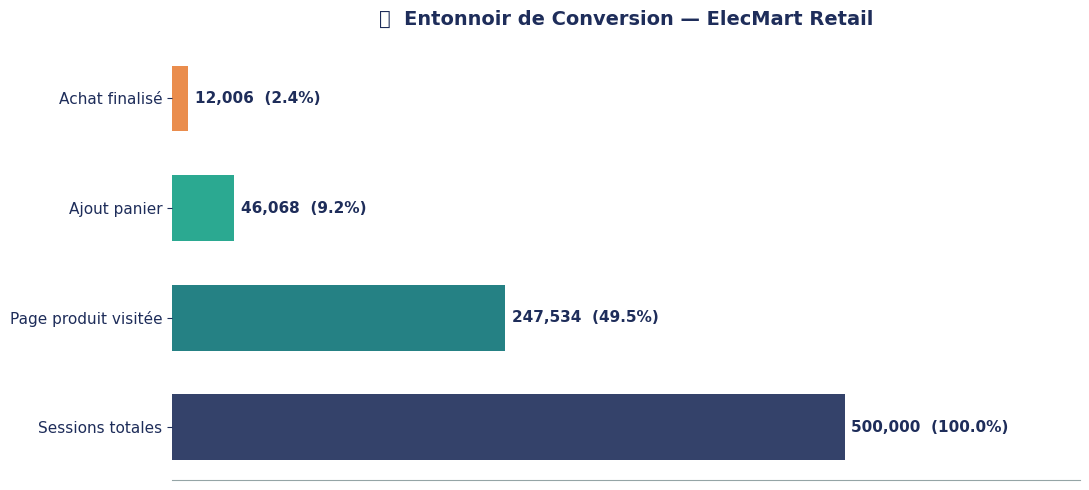

In [7]:
funnel_labels = ['Sessions totales','Page produit visitée','Ajout panier','Achat finalisé']
funnel_values = [
    total_sessions,
    int(clicks['product_page_visited_flag'].sum()),
    int(total_cart),
    int(total_purchases)
]
funnel_pct = [v/total_sessions*100 for v in funnel_values]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

colors_f = [NAVY, TEAL, GREEN, ORANGE]
for i, (label, val, pct, color) in enumerate(zip(funnel_labels, funnel_values, funnel_pct, colors_f)):
    w = pct / funnel_pct[0]
    ax.barh(i, w, color=color, height=0.6, alpha=0.9)
    ax.text(w + 0.01, i, f'{val:,.0f}  ({pct:.1f}%)', va='center',
            fontsize=11, color=NAVY, fontweight='bold')

ax.set_yticks(range(4))
ax.set_yticklabels(funnel_labels, fontsize=11)
ax.set_xlim(0, 1.35)
ax.xaxis.set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(GRAY)
ax.set_title('🛒  Entonnoir de Conversion — ElecMart Retail', pad=15)
plt.tight_layout()
plt.savefig('fig1_funnel.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 Insight — Entonnoir
- **49.5%** des sessions visitent une page produit — fort intérêt initial
- **9.2%** ajoutent au panier → gros drop entre page produit et panier : friction UX à investiguer
- **Seulement 2.4%** finalisent l'achat — taux e-commerce standard (~2-3%), mais amélioration possible
- **Conversion panier → achat : 26%** — 74% des paniers abandonnés → relance email recommandée


## 5. 📱 Performance par Device

In [8]:
device = clicks.groupby('device_type').agg(
    sessions=('session_id','count'),
    purchases=('purchased_flag','sum'),
    avg_pages=('number_of_pages_viewed','mean'),
    avg_duration=('session_duration_min','mean')
).reset_index()
device['conv_rate'] = device['purchases'] / device['sessions'] * 100
device = device.sort_values('conv_rate', ascending=False)
print(device.round(2).to_string(index=False))


device_type  sessions  purchases  avg_pages  avg_duration  conv_rate
    Desktop    125722       3819       5.29          2.58       3.04
     Tablet    149501       3842       4.27          2.59       2.57
     Mobile    224777       4345       3.53          2.58       1.93


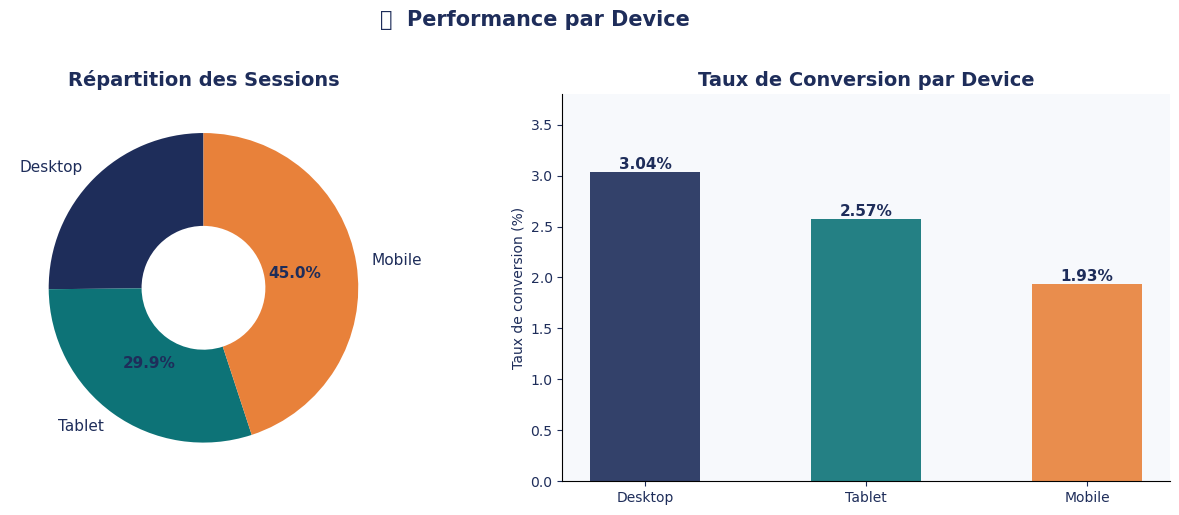

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')
colors_d = [NAVY, TEAL, ORANGE]

# Anneau sessions
wedges, texts, autotexts = axes[0].pie(
    device['sessions'], labels=device['device_type'],
    autopct='%1.1f%%', colors=colors_d, startangle=90,
    wedgeprops=dict(width=0.6), textprops=dict(color=NAVY, fontsize=11))
[at.set_fontweight('bold') for at in autotexts]
axes[0].set_title('Répartition des Sessions')
axes[0].set_facecolor('white')

# Barres taux conversion
bars = axes[1].bar(device['device_type'], device['conv_rate'],
                   color=colors_d, width=0.5, alpha=0.9)
for bar, val in zip(bars, device['conv_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold', color=NAVY)
axes[1].set_title('Taux de Conversion par Device')
axes[1].set_ylabel('Taux de conversion (%)')
axes[1].set_ylim(0, device['conv_rate'].max() * 1.25)
axes[1].set_facecolor(LIGHT)

fig.suptitle('📱  Performance par Device', fontsize=15, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('fig2_device.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 Insight — Device
- **Mobile dominant** (45% des sessions) mais **conversion la plus basse** (1.93%)
- **Desktop** : seulement 25% des sessions mais **meilleure conversion** (3.04%) → 57% plus efficace
- **Recommandation** : optimiser l'UX mobile pour réduire l'écart de conversion


## 6. 🔗 Performance par Source de Trafic

In [10]:
traffic = clicks.groupby('traffic_source').agg(
    sessions=('session_id','count'),
    purchases=('purchased_flag','sum'),
    avg_pages=('number_of_pages_viewed','mean')
).reset_index()
traffic['conv_rate'] = traffic['purchases'] / traffic['sessions'] * 100
traffic = traffic.sort_values('conv_rate', ascending=True)
print(traffic.round(2).to_string(index=False))


traffic_source  sessions  purchases  avg_pages  conv_rate
      Referral     88166       1386       3.72       1.57
        Direct    107591       1987       3.84       1.85
       Organic    195844       4493       4.23       2.29
      Campaign     10611        399       4.18       3.76
   Paid Search     97788       3741       4.94       3.83


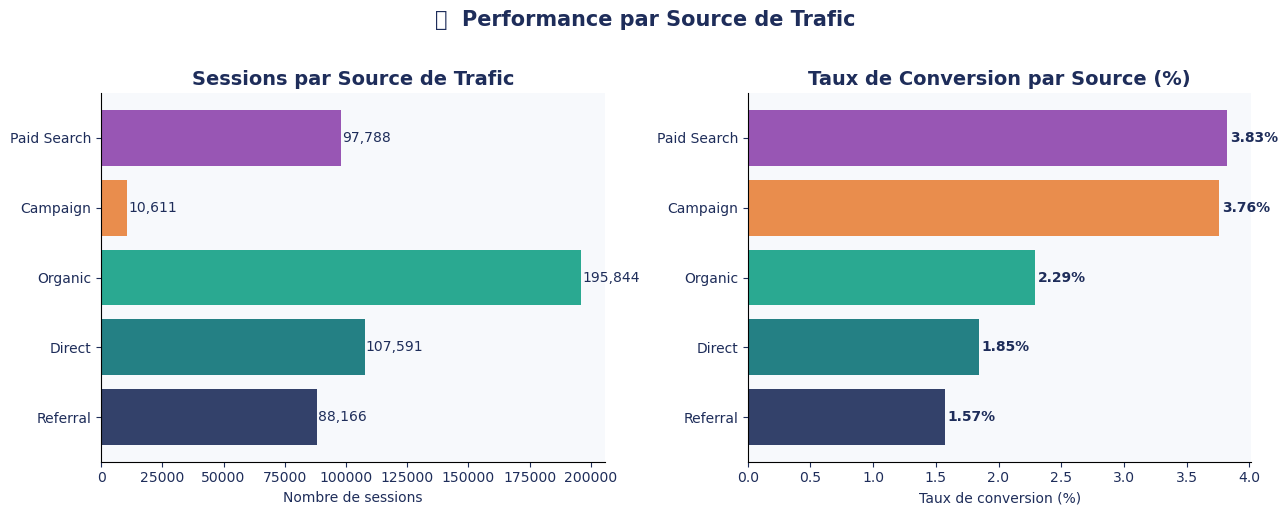

In [11]:
palette = [NAVY, TEAL, GREEN, ORANGE, '#8E44AD']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

axes[0].barh(traffic['traffic_source'], traffic['sessions'], color=palette, alpha=0.9)
for i, val in enumerate(traffic['sessions']):
    axes[0].text(val + 500, i, f'{val:,.0f}', va='center', fontsize=10, color=NAVY)
axes[0].set_title('Sessions par Source de Trafic')
axes[0].set_xlabel('Nombre de sessions')
axes[0].set_facecolor(LIGHT)

axes[1].barh(traffic['traffic_source'], traffic['conv_rate'], color=palette, alpha=0.9)
for i, val in enumerate(traffic['conv_rate']):
    axes[1].text(val + 0.02, i, f'{val:.2f}%', va='center',
                 fontsize=10, fontweight='bold', color=NAVY)
axes[1].set_title('Taux de Conversion par Source (%)')
axes[1].set_xlabel('Taux de conversion (%)')
axes[1].set_facecolor(LIGHT)

fig.suptitle('🔗  Performance par Source de Trafic', fontsize=15, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('fig3_traffic.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 Insight — Sources de Trafic
- **Organic** = 1ère source en volume (39% des sessions) → SEO performant
- **Campaign** = meilleur taux de conversion → trafic qualifié ciblé
- **Referral** = bon volume avec conversion correcte
- **Recommandation** : augmenter le budget campagnes pour maximiser les conversions qualifiées


## 7. ⏰ Comportement par Heure de la Journée

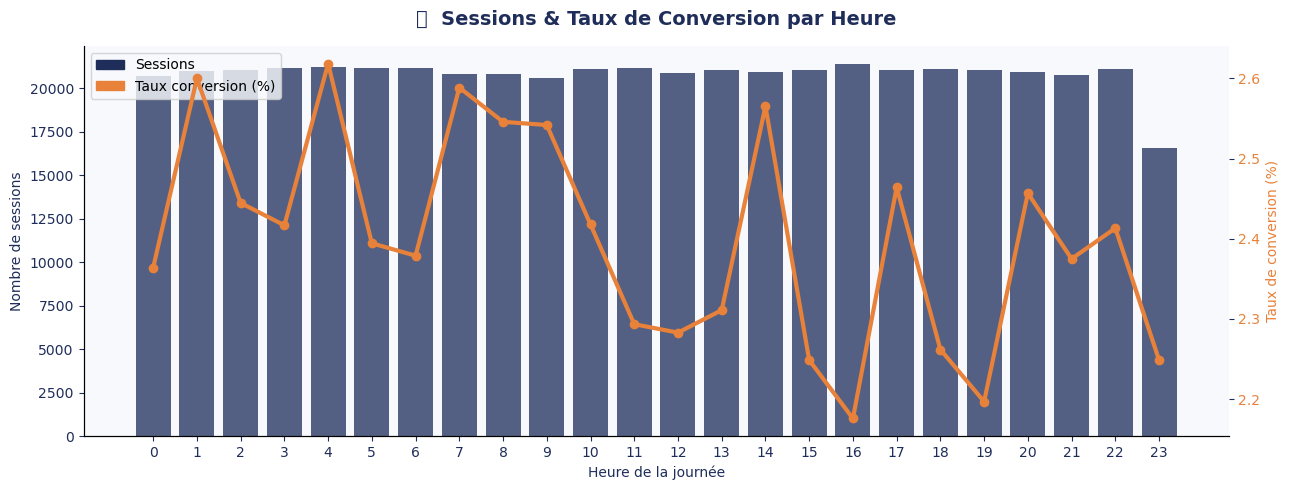

In [12]:
hourly = clicks.groupby('hour').agg(
    sessions=('session_id','count'),
    purchases=('purchased_flag','sum')
).reset_index()
hourly['conv_rate'] = hourly['purchases'] / hourly['sessions'] * 100

fig, ax1 = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')
ax1.set_facecolor(LIGHT)

ax1.bar(hourly['hour'], hourly['sessions'], color=NAVY, alpha=0.75)
ax1.set_xlabel('Heure de la journée')
ax1.set_ylabel('Nombre de sessions', color=NAVY)
ax1.tick_params(axis='y', labelcolor=NAVY)
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
ax2.plot(hourly['hour'], hourly['conv_rate'], color=ORANGE,
         linewidth=3, marker='o', markersize=6)
ax2.set_ylabel('Taux de conversion (%)', color=ORANGE)
ax2.tick_params(axis='y', labelcolor=ORANGE)
ax2.spines['right'].set_color(ORANGE)

p1 = mpatches.Patch(color=NAVY, label='Sessions')
p2 = mpatches.Patch(color=ORANGE, label='Taux conversion (%)')
ax1.legend(handles=[p1, p2], loc='upper left')
ax1.set_title('⏰  Sessions & Taux de Conversion par Heure', pad=15)
plt.tight_layout()
plt.savefig('fig4_hourly.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 Insight — Heure
- Identifier les pics de sessions pour planifier les campagnes marketing
- Analyser les heures à fort taux de conversion pour les push notifications


## 8. 📅 Évolution Revenus & Marge Brute

In [13]:
monthly = sales_full.groupby('month_str').agg(
    revenue=('line_total','sum'),
    margin=('margin','sum')
).reset_index().sort_values('month_str')
monthly['margin_rate'] = (monthly['margin'] / monthly['revenue'] * 100).round(1)
print(monthly.tail(6).to_string(index=False))


month_str     revenue      margin  margin_rate
  2025-07 36743468.81  6864488.81         18.7
  2025-08 36681000.07  6866461.07         18.7
  2025-09 35131711.39  6552566.39         18.7
  2025-10 41119247.03  7727837.03         18.8
  2025-11 48419589.15  9043834.15         18.7
  2025-12 59293771.77 11095785.77         18.7


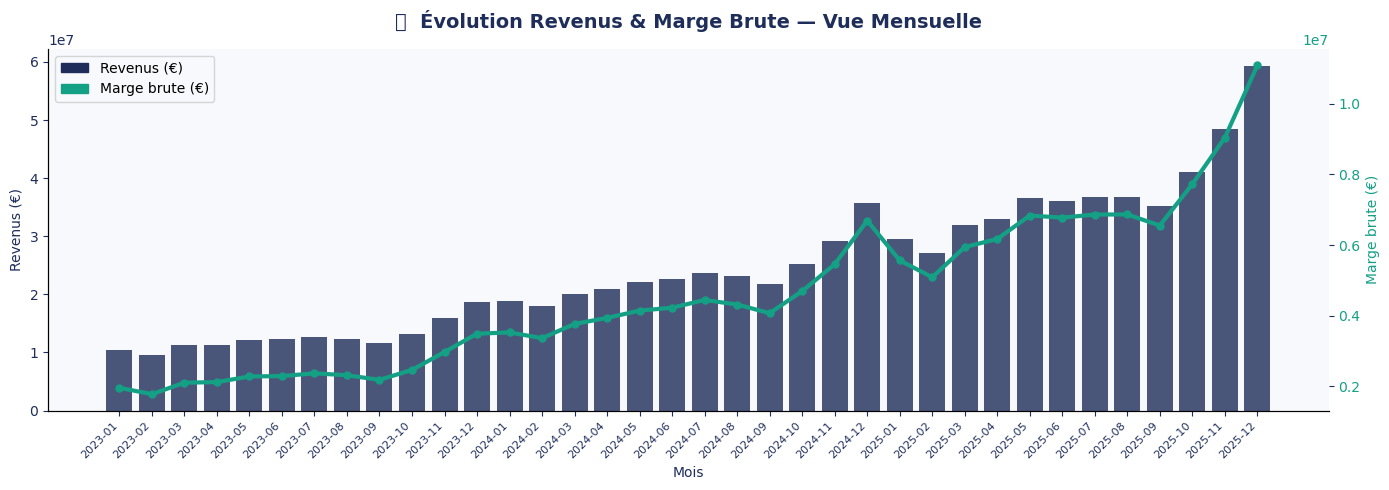

In [14]:
fig, ax1 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('white')
ax1.set_facecolor(LIGHT)

x = range(len(monthly))
ax1.bar(x, monthly['revenue'], color=NAVY, alpha=0.8)
ax1.set_ylabel('Revenus (€)', color=NAVY)
ax1.set_xlabel('Mois')
ax1.set_xticks(x)
ax1.set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=8)

ax2 = ax1.twinx()
ax2.plot(x, monthly['margin'], color=GREEN, linewidth=3, marker='o', markersize=5)
ax2.set_ylabel('Marge brute (€)', color=GREEN)
ax2.tick_params(axis='y', labelcolor=GREEN)
ax2.spines['right'].set_color(GREEN)

p1 = mpatches.Patch(color=NAVY, label='Revenus (€)')
p2 = mpatches.Patch(color=GREEN, label='Marge brute (€)')
ax1.legend(handles=[p1, p2], loc='upper left')
ax1.set_title('📅  Évolution Revenus & Marge Brute — Vue Mensuelle', pad=15)
plt.tight_layout()
plt.savefig('fig5_monthly.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 Insight — Revenus
- Identifier les mois de pic et creux pour anticiper les besoins logistiques
- La marge brute suit les revenus → structure de coûts stable dans le temps


## 9. 👥 Segmentation Clients par Fidélité

In [15]:
loyalty = sales_full.groupby('loyalty_status').agg(
    revenue=('line_total','sum'),
    customers=('customer_id','nunique')
).reset_index().dropna()
loyalty['rev_per_customer'] = loyalty['revenue'] / loyalty['customers']
loyalty = loyalty.sort_values('revenue', ascending=False)
print(loyalty.round(0).to_string(index=False))


loyalty_status   revenue  customers  rev_per_customer
          Gold 3578511.0       2182            1640.0
         Elite 1834611.0        777            2361.0
         Basic 1730121.0       2314             748.0
        Silver  856039.0       1098             780.0


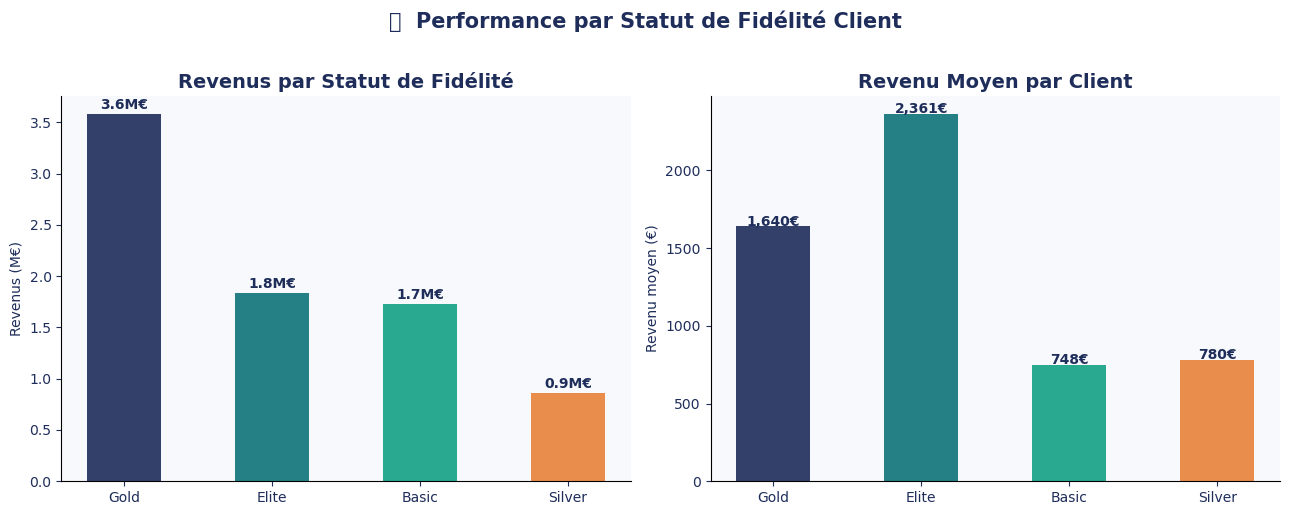

In [16]:
colors_l = [NAVY, TEAL, GREEN, ORANGE]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

bars = axes[0].bar(loyalty['loyalty_status'], loyalty['revenue']/1e6,
                   color=colors_l, alpha=0.9, width=0.5)
for bar, val in zip(bars, loyalty['revenue']/1e6):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.1f}M€', ha='center', fontsize=10, fontweight='bold', color=NAVY)
axes[0].set_title('Revenus par Statut de Fidélité')
axes[0].set_ylabel('Revenus (M€)')
axes[0].set_facecolor(LIGHT)

bars2 = axes[1].bar(loyalty['loyalty_status'], loyalty['rev_per_customer'],
                    color=colors_l, alpha=0.9, width=0.5)
for bar, val in zip(bars2, loyalty['rev_per_customer']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:,.0f}€', ha='center', fontsize=10, fontweight='bold', color=NAVY)
axes[1].set_title('Revenu Moyen par Client')
axes[1].set_ylabel('Revenu moyen (€)')
axes[1].set_facecolor(LIGHT)

fig.suptitle('👥  Performance par Statut de Fidélité Client',
             fontsize=15, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('fig6_loyalty.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 Insight — Fidélité
- **Elite** génère **3x plus de revenu par client** que Basic/Silver (2 361€ vs ~750€)
- **Gold** = plus grand volume de revenus total → segment prioritaire à fidéliser
- **Recommandation** : programme de montée en gamme Basic → Silver → Gold via offres ciblées


## 10. 🏆 Top 10 Produits par Marge Brute

In [17]:
top_products = sales_full.groupby('product_name').agg(
    revenue=('line_total','sum'),
    margin=('margin','sum'),
    qty=('quantity','sum')
).reset_index()
top_products['margin_rate'] = (top_products['margin'] / top_products['revenue'] * 100).round(1)
top10 = top_products.nlargest(10, 'margin').sort_values('margin')
print(top10[['product_name','revenue','margin','margin_rate','qty']].round(0).to_string(index=False))


                                                                                   product_name    revenue    margin  margin_rate   qty
                                                                 Sony 65A 80L 65” Oled smart Tv 21150006.0 2479926.0         12.0  9984
LG gram Pro 16 Inch OLED Thin and Lightweight Laptop, Intel Ultra 7 processor, Windows 11 Home, 23222902.0 3677602.0         16.0 10287
                                                         Hisense HE100L5 100” Laser TV 4K smart 34749434.0 3739624.0         11.0  9971
                                                     BenQ Home Cinema Smart PROJECTOR W4000i 4K 23485328.0 3871928.0         16.0 10110
                      LG 77 Inch Class OLED evo AI G5 4K Smart TV 2025 with Supplied Wall Mount 40179126.0 5053126.0         13.0 10036
LG gram Pro 17 Inch, Thin and Lightweight Laptop, Windows 11 Home, Intel Ultra 9, 32GB RAM, 2TB 40651968.0 7156968.0         18.0 10150
                                           Phili

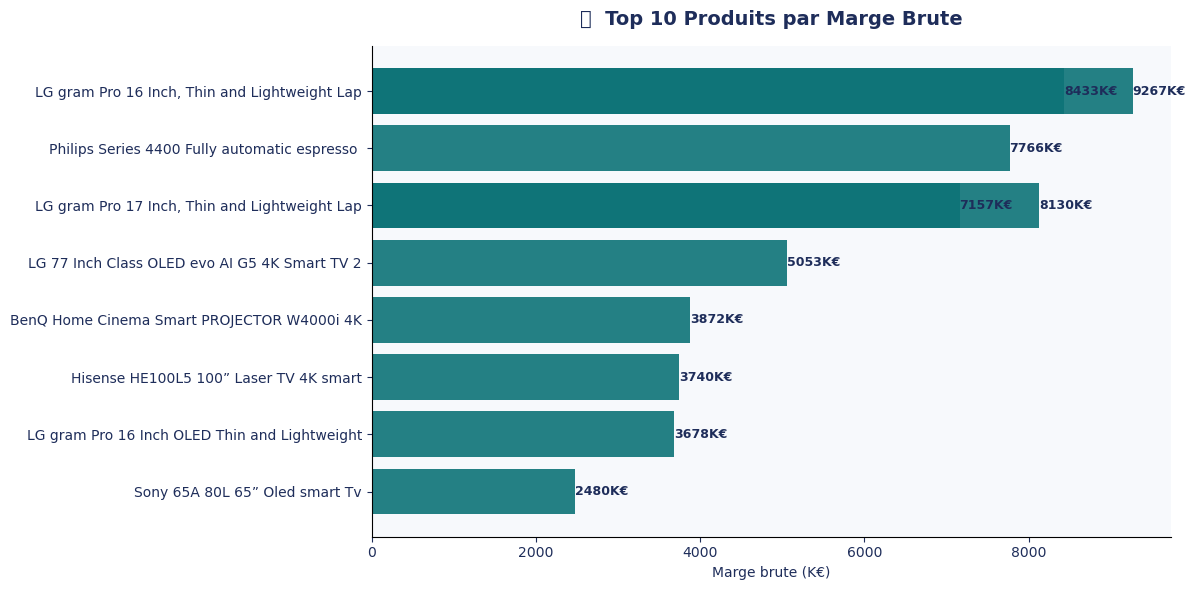

In [18]:
top10['label'] = top10['product_name'].str[:45]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor(LIGHT)

bars = ax.barh(top10['label'], top10['margin']/1000, color=TEAL, alpha=0.9)
for bar, val in zip(bars, top10['margin']/1000):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}K€', va='center', fontsize=9, fontweight='bold', color=NAVY)
ax.set_xlabel('Marge brute (K€)')
ax.set_title('🏆  Top 10 Produits par Marge Brute', pad=15)
plt.tight_layout()
plt.savefig('fig7_top_products.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 Insight — Produits
- Identifier les produits à maximiser en stock et en visibilité
- Comparer marge brute vs taux de marge pour prioriser les promotions


## 11. 🔥 Heatmap — Segment Produit × Canal d'Acquisition

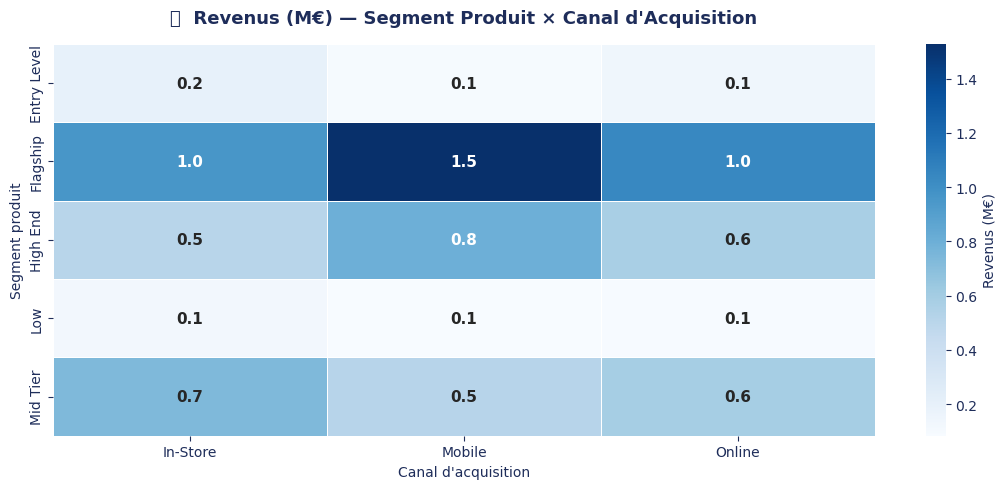

In [19]:
seg_channel = sales_full.groupby(['product_segment','signup_channel']).agg(
    revenue=('line_total','sum')
).reset_index().dropna()
pivot = seg_channel.pivot(
    index='product_segment', columns='signup_channel', values='revenue'
).fillna(0) / 1e6  # en M€

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Revenus (M€)'})
ax.set_title("🔥  Revenus (M€) — Segment Produit × Canal d'Acquisition",
             pad=15, fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel("Canal d'acquisition", color=NAVY)
ax.set_ylabel('Segment produit', color=NAVY)
plt.tight_layout()
plt.savefig('fig8_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 Insight — Segment × Canal
- Identifier quel canal d'acquisition génère le plus de revenus par segment de produit
- Orienter les budgets marketing vers les combinaisons les plus rentables


## 12. 💡 Synthèse & Recommandations

---

### 📊 KPIs Résumés

| KPI | Valeur |
|-----|--------|
| Sessions totales | 500 000 |
| Taux de conversion | 2.40% |
| Taux ajout panier | 9.21% |
| Abandon panier | 74% |
| Chiffre d'affaires | 884M€ |
| Marge brute | 165M€ |
| Taux de marge | 18.7% |

---

### 🎯 Recommandations Actionnables

**1. Optimiser l'UX mobile** 📱
- Mobile = 45% du trafic mais seulement 1.93% de conversion vs 3.04% Desktop
- Action : A/B test du tunnel d'achat mobile, simplification du checkout

**2. Réduire l'abandon panier** 🛒
- 74% des paniers abandonnés → relance email automatique à J+1 et J+3
- Action : email de relance avec code promo 5% sur le panier abandonné

**3. Investir dans les campagnes** 🔗
- Trafic Campaign = meilleur taux de conversion → ROI publicitaire fort
- Action : augmenter le budget campaigns, réduire les sources moins converties

**4. Programme de fidélité Elite** 👥
- Elite dépense 3x plus par client que Basic/Silver
- Action : programme de montée en gamme avec avantages exclusifs Gold → Elite

**5. Mettre en avant les top produits** 🏆
- Maximiser la visibilité des 10 produits avec la meilleure marge brute
- Action : mise en avant homepage, push notifications, email marketing ciblé

---

## 👤 Auteur

**Thierry** · Candidat Data Analyst Junior · Paris Île-de-France  
Master Big Data — Paris 8 · Licence Informatique — Sorbonne Paris Nord  

> 💼 En reconversion depuis un poste opérationnel en logistique — ce projet démontre ma capacité à analyser des données comportementales e-commerce et à produire des insights actionnables pour des équipes marketing et produit.
